In [1]:
# Create a clean environment
!python -m venv image_clustering

# Activate it
# On Windows:
!image_clustering\Scripts\activate
# On macOS/Linux:
# source fresh_env/bin/activate

# Now install ONLY the versions we want
!pip install --upgrade pip
!pip install numpy==1.26.4 tensorflow==2.15.0 keras==2.15.0 matplotlib


C:\anc\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


C:\anc\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\anc\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


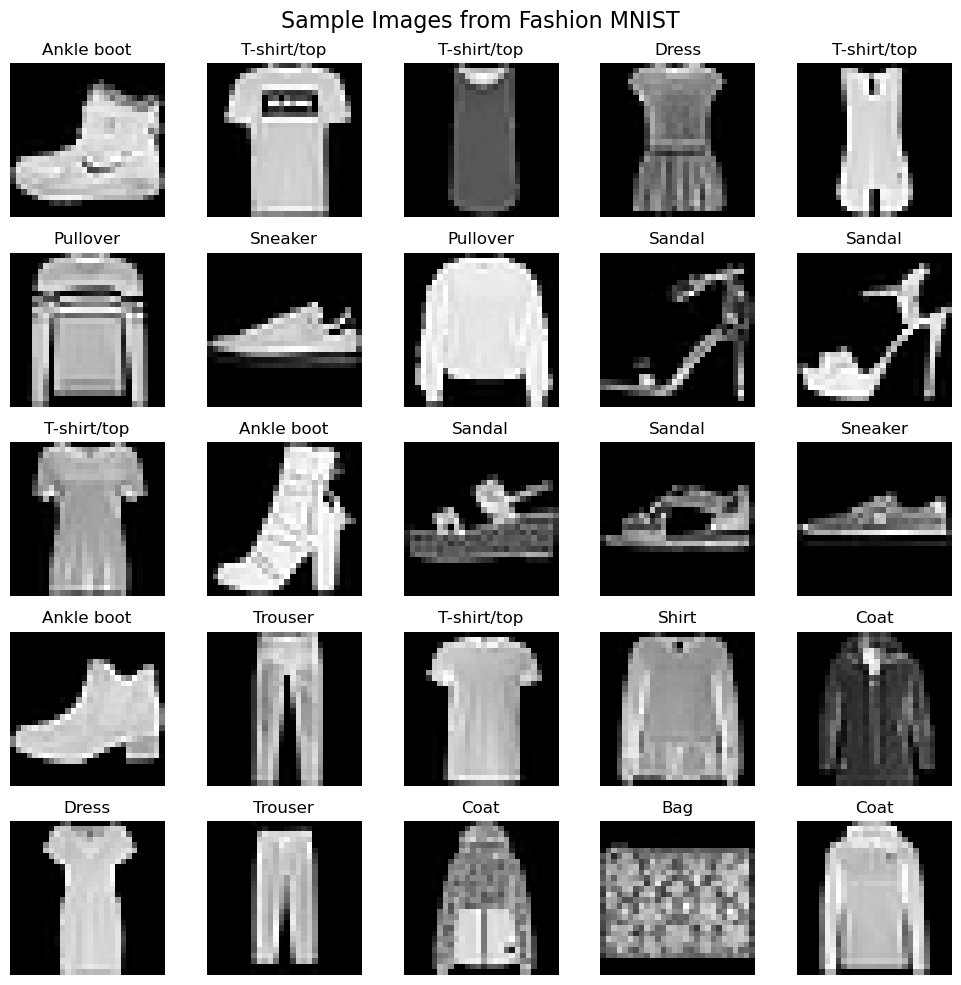

In [2]:
# Step 1: Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import fashion_mnist

# Step 2: Load the Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Step 3: Print dataset dimensions
print("Training data shape:", x_train.shape)  # (60000, 28, 28)
print("Test data shape:", x_test.shape)      # (10000, 28, 28)

# Step 4: Define label names for visualization
label_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# Step 5: Visualize first 25 images with labels
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(label_names[y_train[i]])
    plt.axis('off')
plt.suptitle("Sample Images from Fashion MNIST", fontsize=16)
plt.tight_layout()
plt.show()


New shape of x_train: (60000, 784)
New shape of x_test: (10000, 784)


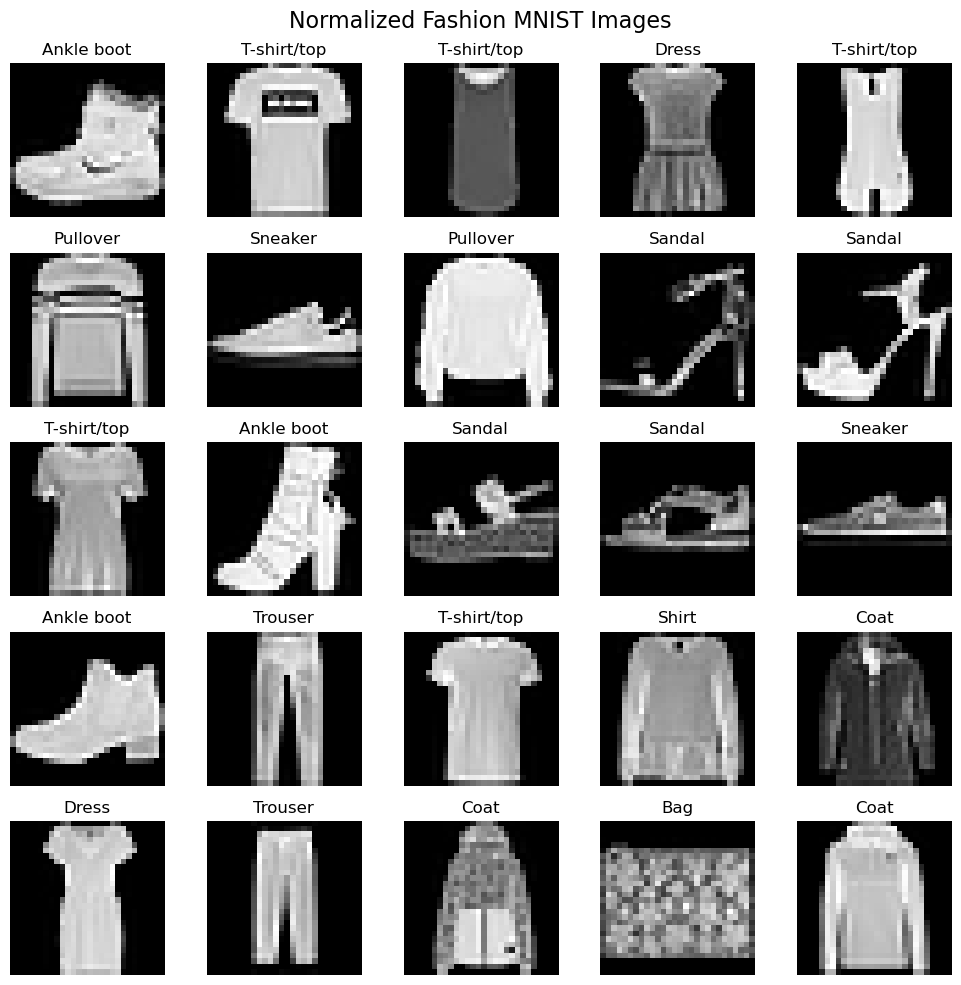

In [3]:
# Step 1: Reshape the image data from (28, 28) to (784,)
x_train_reshaped = x_train.reshape(-1, 28*28)
x_test_reshaped = x_test.reshape(-1, 28*28)

print("New shape of x_train:", x_train_reshaped.shape)  # (60000, 784)
print("New shape of x_test:", x_test_reshaped.shape)    # (10000, 784)

# Step 2: Normalize pixel values to the range [0, 1]
x_train_normalized = x_train_reshaped / 255.0
x_test_normalized = x_test_reshaped / 255.0

# Step 3: Visualize some normalized images (reshape back to 28x28 for display)
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(x_train_normalized[i].reshape(28, 28), cmap='gray')
    plt.title(label_names[y_train[i]])
    plt.axis('off')
plt.suptitle("Normalized Fashion MNIST Images", fontsize=16)
plt.tight_layout()
plt.show()


Cluster distribution:
 Predicted
2    9614
4    9085
6    7759
8    7454
5    7386
1    6535
3    4257
0    2986
9    2564
7    2360
Name: count, dtype: int64


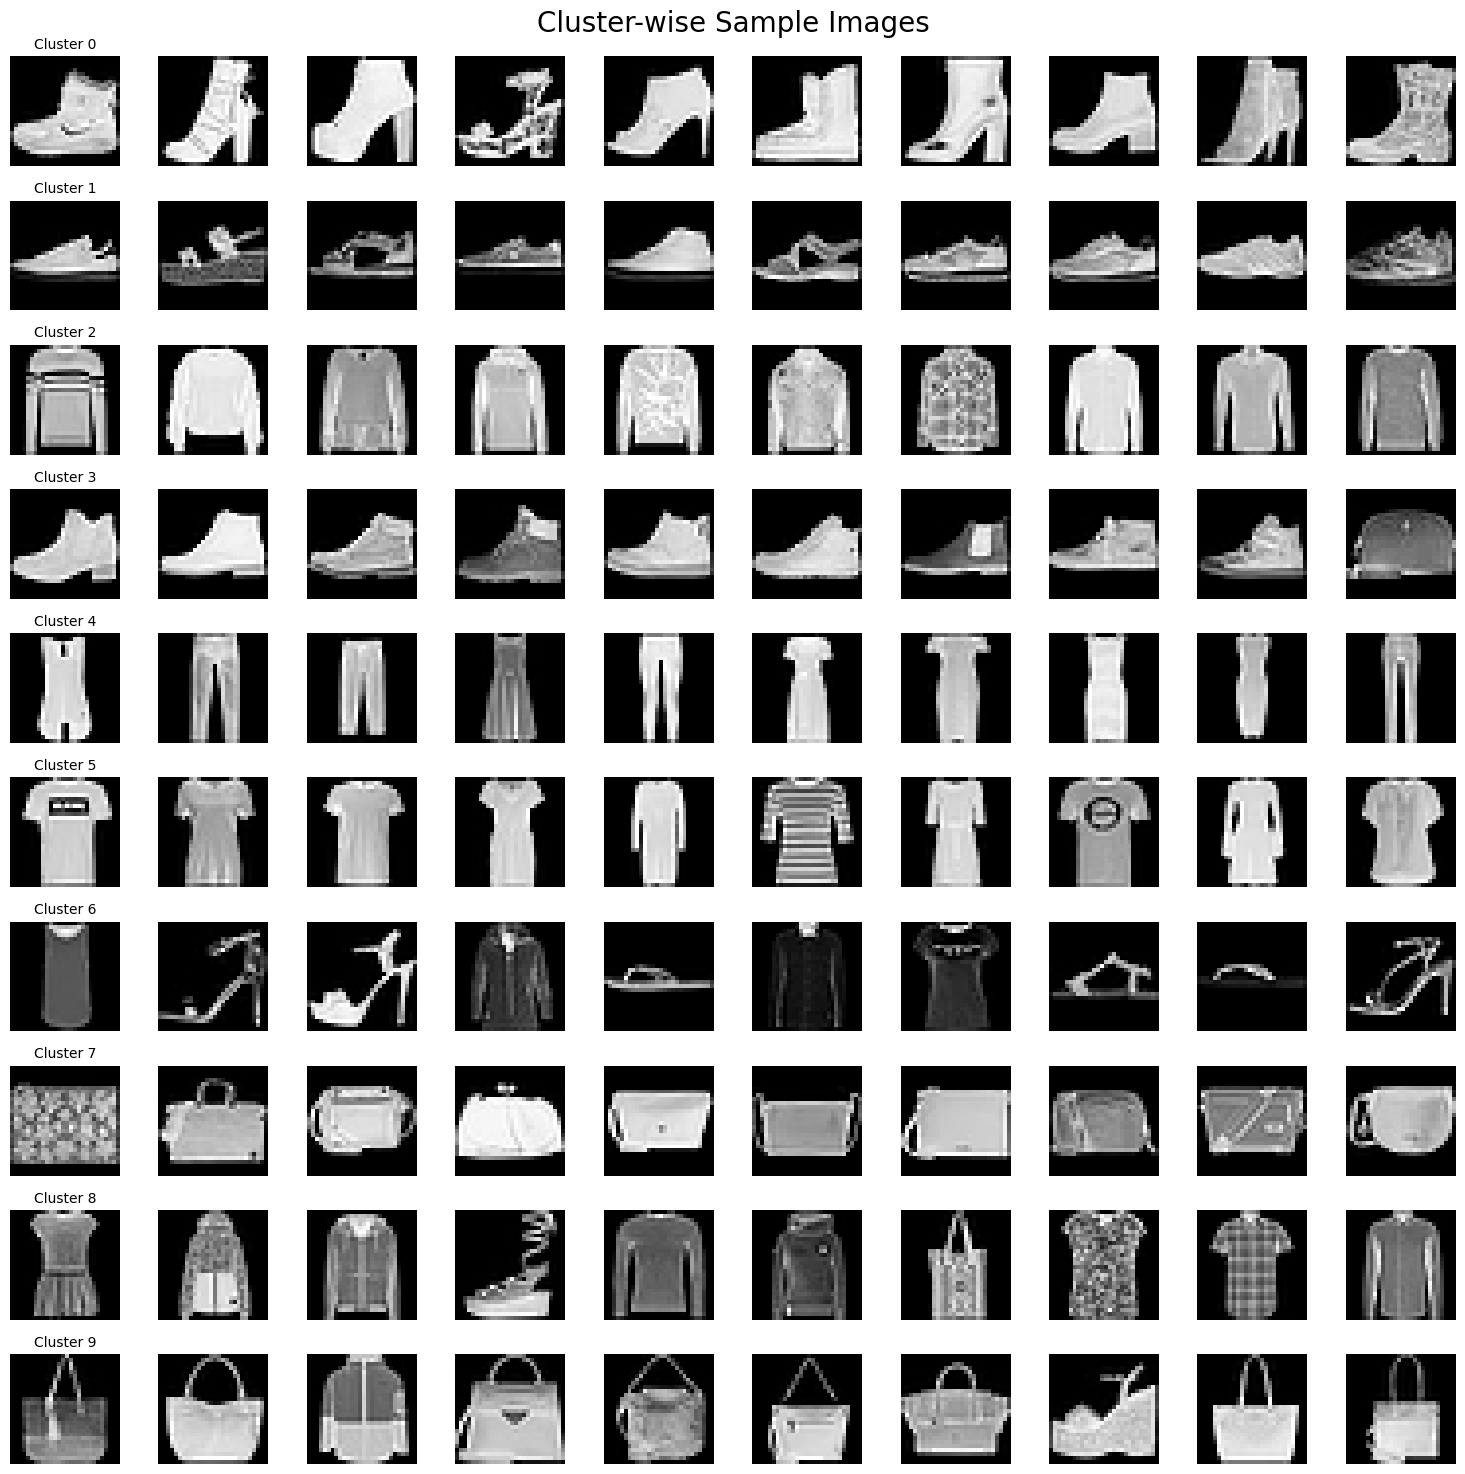

In [4]:
from sklearn.cluster import KMeans
import numpy as np

# Apply KMeans with 10 clusters
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
kmeans.fit(x_train_normalized)

# Predicted cluster labels for each image
cluster_labels = kmeans.labels_

# Create a DataFrame to map original and predicted clusters
import pandas as pd
kmeans_df = pd.DataFrame({
    'Original': y_train,
    'Predicted': cluster_labels
})

# Show number of images in each cluster
print("Cluster distribution:\n", kmeans_df['Predicted'].value_counts())

# Visualize 10 sample images from each cluster
import matplotlib.pyplot as plt


plt.figure(figsize=(15, 15))
for cluster_num in range(10):
    # Get indices of images in the current cluster
    cluster_indices = np.where(cluster_labels == cluster_num)[0][:10]

    for i, idx in enumerate(cluster_indices):
        plt.subplot(10, 10, cluster_num*10 + i + 1)
        plt.imshow(x_train_normalized[idx].reshape(28, 28), cmap='gray')
        plt.axis('off')
        if i == 0:
            plt.title(f"Cluster {cluster_num}", fontsize=10)
plt.suptitle("Cluster-wise Sample Images", fontsize=20)
plt.tight_layout()
plt.show()


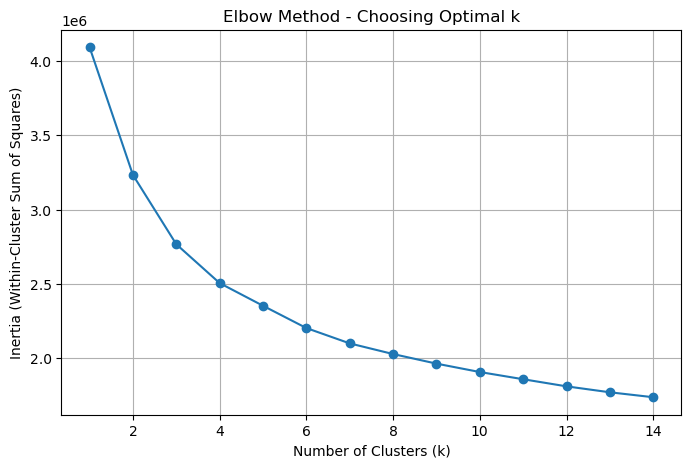

In [5]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_range = range(1, 15)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(x_train_normalized)
    inertia.append(km.inertia_)

# Plot the Elbow graph
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method - Choosing Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.grid(True)
plt.show()


In [7]:
from sklearn.metrics import  accuracy_score

# Map clusters to labels using the mode of true labels in each cluster
import numpy as np
from scipy.stats import mode

labels = np.zeros_like(cluster_labels)
for i in range(10):
    mask = (cluster_labels == i)
    if np.any(mask):
        labels[mask] = mode(y_train[mask])[0]

# Confusion matrix and accuracy

acc = accuracy_score(y_train, labels)


print("Clustering Accuracy: {:.2f}%".format(acc * 100))


Clustering Accuracy: 55.34%


C:\Users\Srivathsan V\AppData\Local\Temp\ipykernel_24928\3833361426.py:11: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  labels[mask] = mode(y_train[mask])[0]


In [8]:
label_names = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}


C:\Users\Srivathsan V\AppData\Local\Temp\ipykernel_24928\1089729848.py:24: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mapped_labels[mask] = mode(y_train[mask])[0]


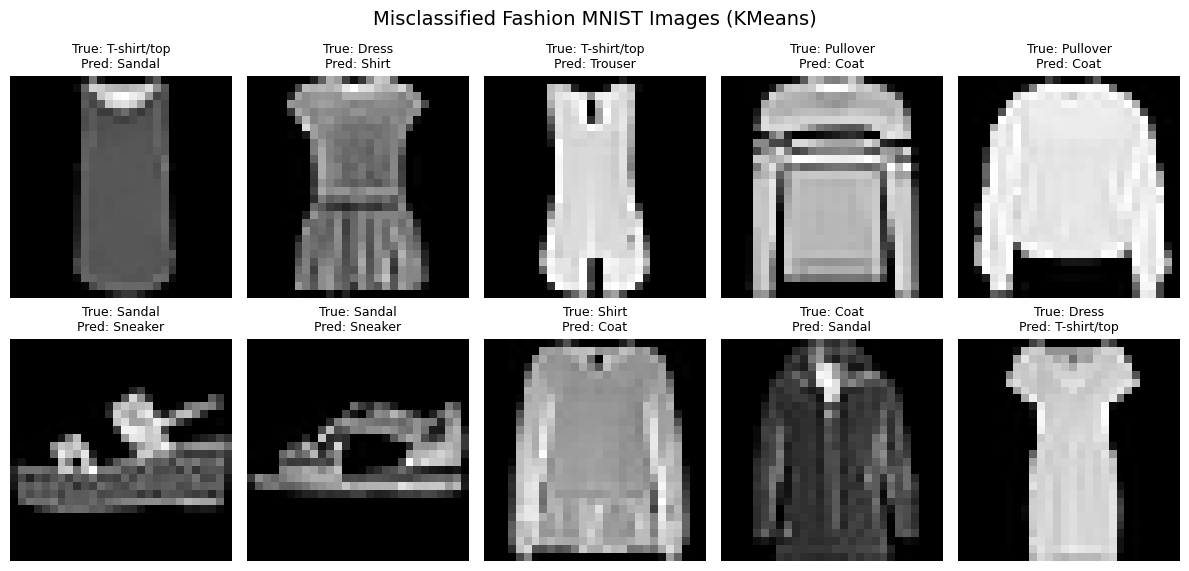

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mode

# Fashion MNIST label names
label_names = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}

# Remap cluster labels to closest true labels using mode
mapped_labels = np.zeros_like(cluster_labels)
for i in range(10):
    mask = (cluster_labels == i)
    if np.any(mask):
        mapped_labels[mask] = mode(y_train[mask])[0]

# Find misclassified indices
misclassified_indices = np.where(mapped_labels != y_train)[0]

# Plot misclassified images with actual labels
plt.figure(figsize=(12, 6))
for i, idx in enumerate(misclassified_indices[:10]):
    true_label = label_names[y_train[idx]]
    pred_label = label_names[mapped_labels[idx]]
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[idx], cmap='gray')
    plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=9)
    plt.axis('off')

plt.suptitle("Misclassified Fashion MNIST Images (KMeans)", fontsize=14)
plt.tight_layout()
plt.show()
